In [42]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
df = sns.load_dataset("titanic")
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [43]:
df.shape

(891, 15)

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [45]:
clasificacion_variables = pd.DataFrame({

    "variable":["survived","pclass","sex","age","sibsp","fare","embarked","deck","alone"],
    "clasificacion":["categorica - nominal","categorica - ordinal", "categorica - nominal","numerica - discreta","numerica - discreta","numerica - continua","categorica - nominal","categorica - nominal","categorica - nominal"]
    }
)
clasificacion_variables

,variable,clasificacion
0,survived,categorica - nominal
1,pclass,categorica - ordinal
2,sex,categorica - nominal
3,age,numerica - discreta
4,sibsp,numerica - discreta
5,fare,numerica - continua
6,embarked,categorica - nominal
7,deck,categorica - nominal
8,alone,categorica - nominal


In [46]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [47]:
valores_nulos = pd.DataFrame({
    "numero_nulos":df.isna().sum(),
    "porcentaje": df.isna().mean()*100
}).sort_values("porcentaje",ascending= False)

valores_nulos

,numero_nulos,porcentaje
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


In [48]:
#HALLAR REGISTROS DUPLICADOS
num_duplicados = df.duplicated().sum()
duplicados= df[df.duplicated(keep=False)].sort_values(list(df.columns))
print(num_duplicados)

107


In [49]:
duplicados.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
64,0,1,male,NaN,0,0,27.7208,C,First,man,True,NaN,Cherbourg,no,True
295,0,1,male,NaN,0,0,27.7208,C,First,man,True,NaN,Cherbourg,no,True
144,0,2,male,18.0,0,0,11.5000,S,Second,man,True,NaN,Southampton,no,True
757,0,2,male,18.0,0,0,11.5000,S,Second,man,True,NaN,Southampton,no,True
658,0,2,male,23.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
733,0,2,male,23.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
734,0,2,male,23.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
134,0,2,male,25.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
343,0,2,male,25.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
666,0,2,male,25.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True


In [50]:
resumen =df[["age","fare"]].agg(["mean","median","std"])
q = df[["age","fare"]].quantile([0.25,0.75]).T
q.columns = ["q1","q3"]
q["iqr"]=q["q3"]-q["q1"]
q

,q1,q3,iqr
age,20.1250,38.0,17.8750
fare,7.9104,31.0,23.0896


In [51]:
resumen

,age,fare
mean,29.699118,32.204208
median,28.000000,14.454200
std,14.526497,49.693429


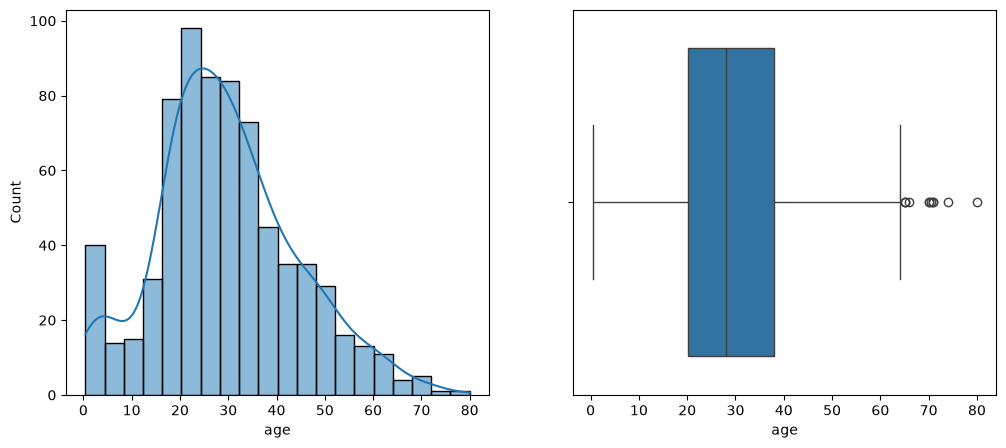

In [52]:
fig,axes = plt.subplots(1,2,figsize =(12,5))
sns.histplot(data=df,x="age",bins=20,kde=True, ax=axes[0])
sns.boxplot(data=df, x="age",ax=axes[1])
plt.show()

age     -6.6875
fare   -26.7240
dtype: float64
age     64.8125
fare    65.6344
dtype: float64


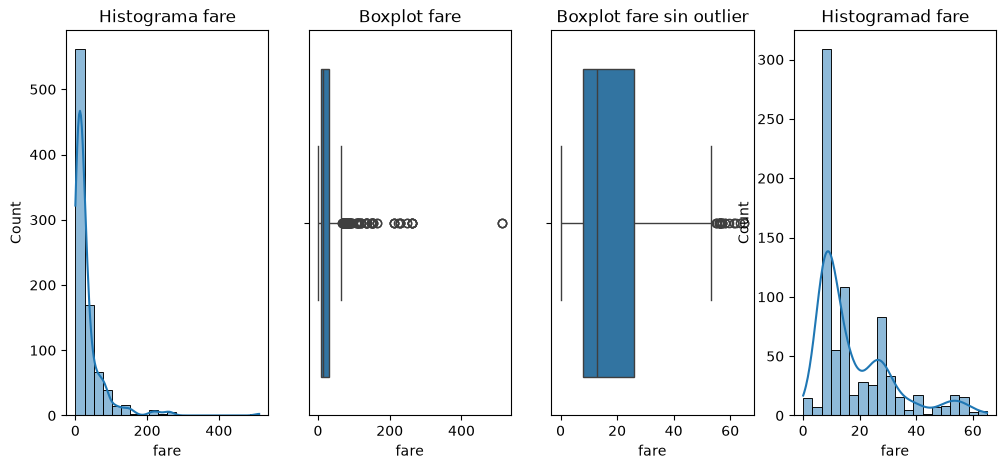

In [61]:
# 7. Analiza "fare" con histograma y boxplot.
# Calcula los límites de outliers mediante la regla 1.5*IQR y cuenta cuántas observaciones quedan fuera
# Pista de trabajo: Un outlier no es automáticamente un error.

fig, axes = plt.subplots(1, 4, figsize=(12, 5))

sns.histplot(data=df, x="fare", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Histograma fare")

sns.boxplot(data=df, x="fare", ax=axes[1])
axes[1].set_title("Boxplot fare")

q = df[["age", "fare"]].quantile([0.25, 0.75]).T
q.columns = ["q1", "q3"]
q["iqr"] = q["q3"] - q["q1"]

lower = q["q1"] - 1.5 * q["iqr"]
print(lower)

upper = q["q3"] + 1.5 * q["iqr"]
print(upper)

df_sin_outlier = df[(df["fare"] > lower["fare"]) & (df["fare"] < upper["fare"])]

sns.boxplot(data=df_sin_outlier, x="fare", ax=axes[2])
axes[2].set_title("Boxplot fare sin outlier")

sns.histplot(data=df_sin_outlier, x="fare", bins=20, kde=True, ax=axes[3])
axes[3].set_title("Histogramad fare")

plt.show()

In [63]:
df_sin_outlier["fare"].max()

np.float64(65.0)

In [64]:
df_sin_outlier["fare"].min()

np.float64(0.0)

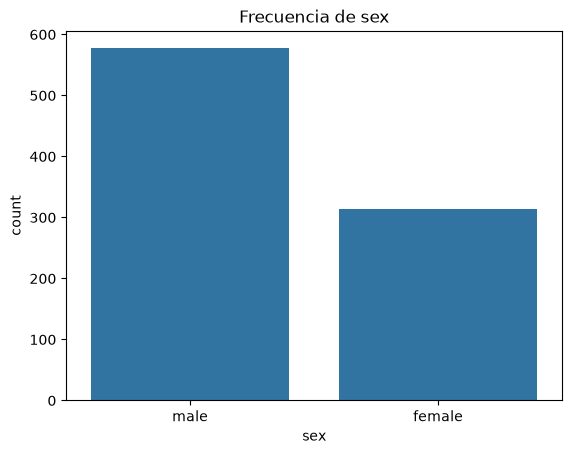

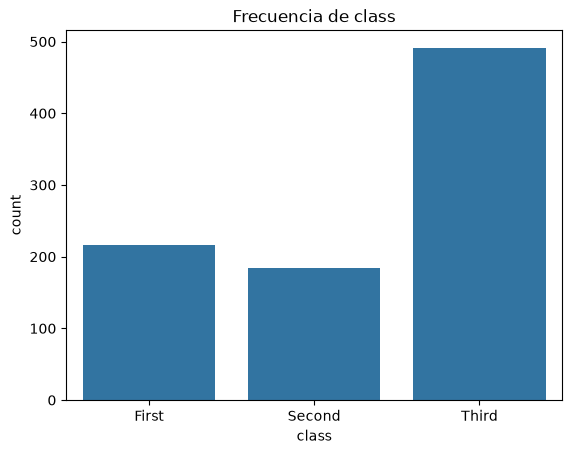

In [65]:
for col in ["sex", "class"]:
    sns.countplot(data=df, x=col)
    plt.title(f"Frecuencia de {col}")
    plt.show()

38.38383838383838


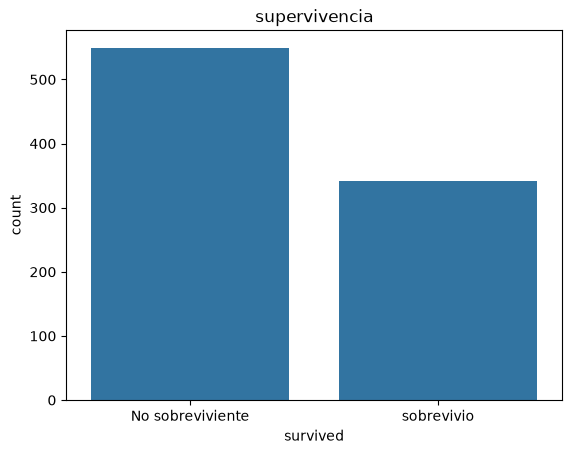

In [70]:
counts = df["survived"].value_counts()
counts
tasa = df["survived"].mean()*100
print(tasa)
sns.countplot(data=df ,x="survived")
plt.xticks([0,1],["No sobreviviente", "sobrevivio"])
plt.title("supervivencia")
plt.show()

<Axes: xlabel='sex', ylabel='survived'>

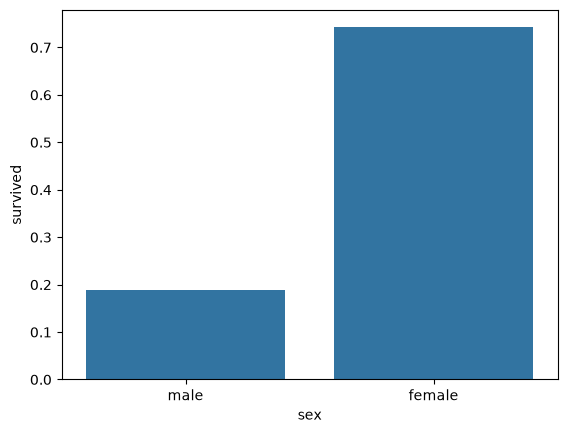

In [72]:
sex_rate = df.groupby("sex")["survived"].agg(["count","mean"])
sex_rate["mean"]*100
sex_rate
sns.barplot(data=df, x="sex", y="survived", errorbar=None)

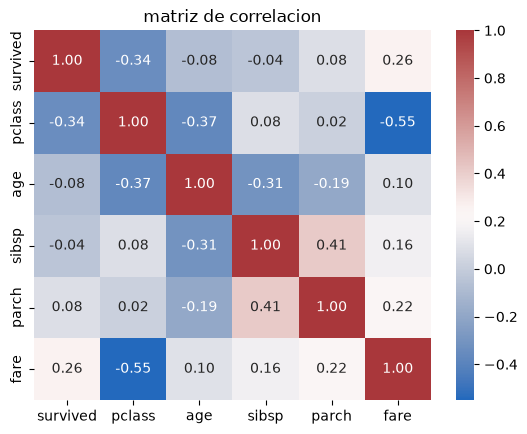

In [75]:
columns_numericas = df.select_dtypes(include = "number")
corr = columns_numericas.corr()
sns.heatmap(corr, annot= True, fmt=".2f",cmap="vlag")
plt.title("matriz de correlacion")
plt.show()


In [76]:
pd.crosstab(df["survived"],df["alive"])

alive,no,yes
survived,,
0,549,0
1,0,342
